# Ejercicio Módulo 5 - Dataset Swiss
**Inteligencia Artificial - CEIA - FIUBA**

**Daniel Alejandro Acero Varela**

Para aprender sobre regresión, vamos a utilizar un dataset clásico llamado Swiss, que proviene originalmente del lenguaje R. Este dataset contiene datos socioeconómicos de 47 provincias suizas a fines del siglo XIX. Cada fila representa una provincia, y las variables reflejan características demográficas y sociales relevantes para ese contexto histórico.

## Variables

- `Location`: Provincia donde se midieron los datos.
- `Fertility`: Tasa de fertilidad (número promedio de hijos por mujer)
- `Agriculture`:` Porcentaje de hombres ocupados en agricultura
- `Examination`: Porcentaje de hombres que completaron exámenes de educación superior
- `Education`: Nivel promedio de educación (escala arbitraria)
- `Catholic`: Porcentaje de población católica
- `Infant.Mortality`: Tasa de mortalidad infantil (por cada 1000 nacidos vivos)

## Que queremos predecir?

Vamos a utilizar este dataset para predecir la tasa de fertilidad en cada provincia mediante diferentes métodos de regresión.

---

Siguiendo el procedimiento típico de Machine Learning, vamos a leer los datos y separarlos en los datasets de entrenamiento y testeo utilizando Scikit-Learn...

In [167]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("swiss.csv")

df.head()

,Location,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
0,Courtelary,80.2,17.0,15,12,9.96,22.2
1,Delemont,83.1,45.1,6,9,84.84,22.2
2,Franches-Mnt,92.5,39.7,5,5,93.40,20.2
3,Moutier,85.8,36.5,12,7,33.77,20.3
4,Neuveville,76.9,43.5,17,15,5.16,20.6


In [168]:
df.tail()

,Location,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
42,Val de Ruz,77.6,37.6,15,7,4.97,20.0
43,ValdeTravers,67.6,18.7,25,7,8.65,19.5
44,V. De Geneve,35.0,1.2,37,53,42.34,18.0
45,Rive Droite,44.7,46.6,16,29,50.43,18.2
46,Rive Gauche,42.8,27.7,22,29,58.33,19.3


In [169]:
df.describe(include='O')

,Location
count,47
unique,47
top,Courtelary
freq,1


In [170]:
print(f"Tenemos {df.Location.nunique()} categorías en 'Location'. Estas son:")
df["Location"].unique()

Tenemos 47 categorías en 'Location'. Estas son:


array(['Courtelary', 'Delemont', 'Franches-Mnt', 'Moutier', 'Neuveville',
       'Porrentruy', 'Broye', 'Glane', 'Gruyere', 'Sarine', 'Veveyse',
       'Aigle', 'Aubonne', 'Avenches', 'Cossonay', 'Echallens',
       'Grandson', 'Lausanne', 'La Vallee', 'Lavaux', 'Morges', 'Moudon',
       'Nyone', 'Orbe', 'Oron', 'Payerne', "Paysd'enhaut", 'Rolle',
       'Vevey', 'Yverdon', 'Conthey', 'Entremont', 'Herens', 'Martigwy',
       'Monthey', 'St Maurice', 'Sierre', 'Sion', 'Boudry',
       'La Chauxdfnd', 'Le Locle', 'Neuchatel', 'Val de Ruz',
       'ValdeTravers', 'V. De Geneve', 'Rive Droite', 'Rive Gauche'],
      dtype=object)

In [171]:
print(f"Tenemos {df.shape[0]} observaciones")

Tenemos 47 observaciones


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          47 non-null     object 
 1   Fertility         47 non-null     float64
 2   Agriculture       47 non-null     float64
 3   Examination       47 non-null     int64  
 4   Education         47 non-null     int64  
 5   Catholic          47 non-null     float64
 6   Infant.Mortality  47 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 2.7+ KB


Obtenemos la variable objetivo (`Fertility`) y, por otro lado, los atributos (quitamos `Location` ya que no es un atributo numérico relevante para la regresión)

In [173]:
X = df.drop(["Fertility", "Location"], axis=1) # Búsqueda y descarte vertical
y = df["Fertility"]

Dado que tenemos pocas observaciones, vamos a separar el dataset en un 50% para entrenamiento y 50% para testeo:

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


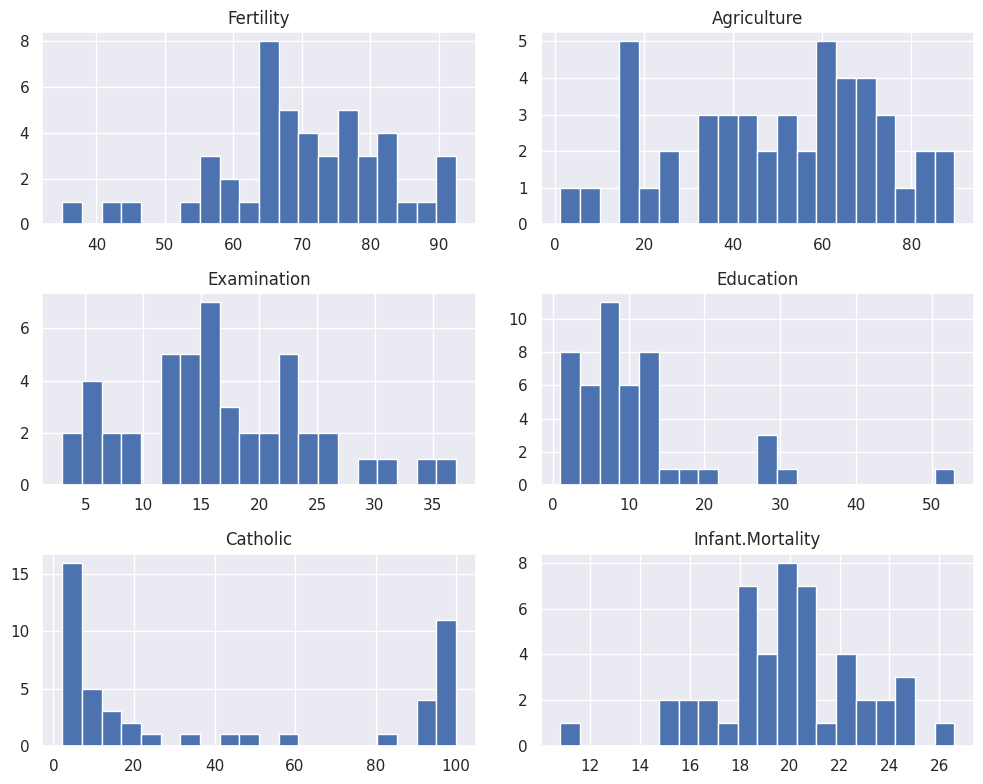

In [175]:
import matplotlib.pyplot as plt

# Genera una cuadrícula con el histograma de cada columna numérica
df.hist(figsize=(10, 8), bins=20, edgecolor='white')
plt.tight_layout()
plt.show()


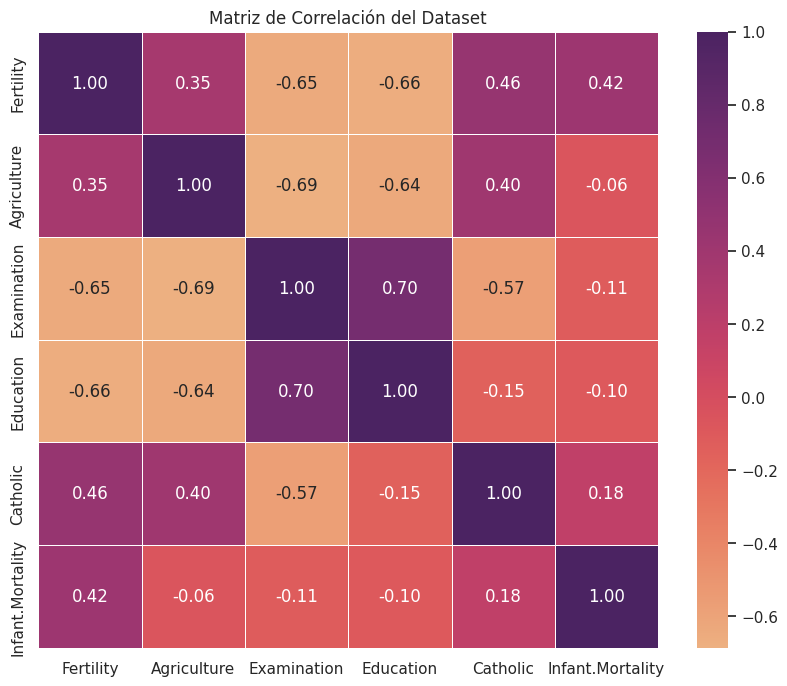

In [176]:
# Suponiendo que tu dataset se llama 'df'
# 1. Calculamos la matriz de correlación (solo de columnas numéricas)
corr = df.corr(numeric_only=True)

# 2. Creamos el mapa de calor
plt.figure(figsize=(10, 8)) # Ajusta el tamaño de la ventana
sns.heatmap(corr, annot=True, cmap='flare', fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación del Dataset')
plt.show()


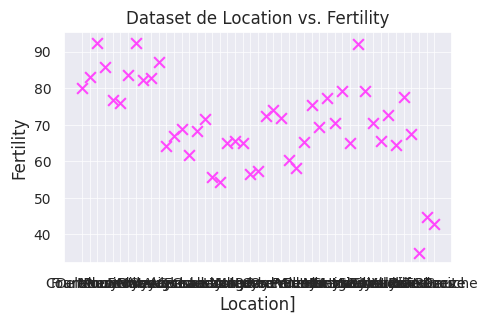

In [177]:
plt.figure(figsize=(5, 3))
plt.scatter(df['Location'], df['Fertility'], color='#ff48fd',
    marker="x", s=60)
plt.grid(True, linewidth=0.5)
plt.xlabel('Location]', fontsize=12)
plt.ylabel('Fertility', fontsize=12)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.title('Dataset de Location vs. Fertility', fontsize=12)
plt.show()

## Regresión lineal múltiple

Arranquemos la primera parte del ejercicio. Para eso, vamos a entrenar un modelo de regresión lineal múltiple usando todos los atributos. Para ello debes:

1. Escalar los atributos usando `StandardScaler`
2. Entrenar el modelo usando el dataset de entrenamiento.
3. Obtener las predicciones sobre el dataset de testeo.
4. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.

In [178]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first') # Corra la columna 1 por estabilidad numérica
encoder.fit(df[["Location"]])
encoded_state = encoder.transform(df[["Location"]]).toarray()
encoded_state[:5, :]
encoded_columns = encoder.get_feature_names_out()
encoded_columns
encoded_df = pd.DataFrame(encoded_state, columns=encoded_columns)

# Unimos las columnas codificadas con el DataFrame original
dataset_with_dummies = pd.concat([df, encoded_df], axis=1)

# Lista de las columnas que SÍ quieres conservar
columnas_validas = ['Fertility', 'Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality']

# Filtramos el DataFrame directamente
dataset_with_dummies = dataset_with_dummies[columnas_validas]

dataset_with_dummies.head()





,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
0,80.2,17.0,15,12,9.96,22.2
1,83.1,45.1,6,9,84.84,22.2
2,92.5,39.7,5,5,93.40,20.2
3,85.8,36.5,12,7,33.77,20.3
4,76.9,43.5,17,15,5.16,20.6


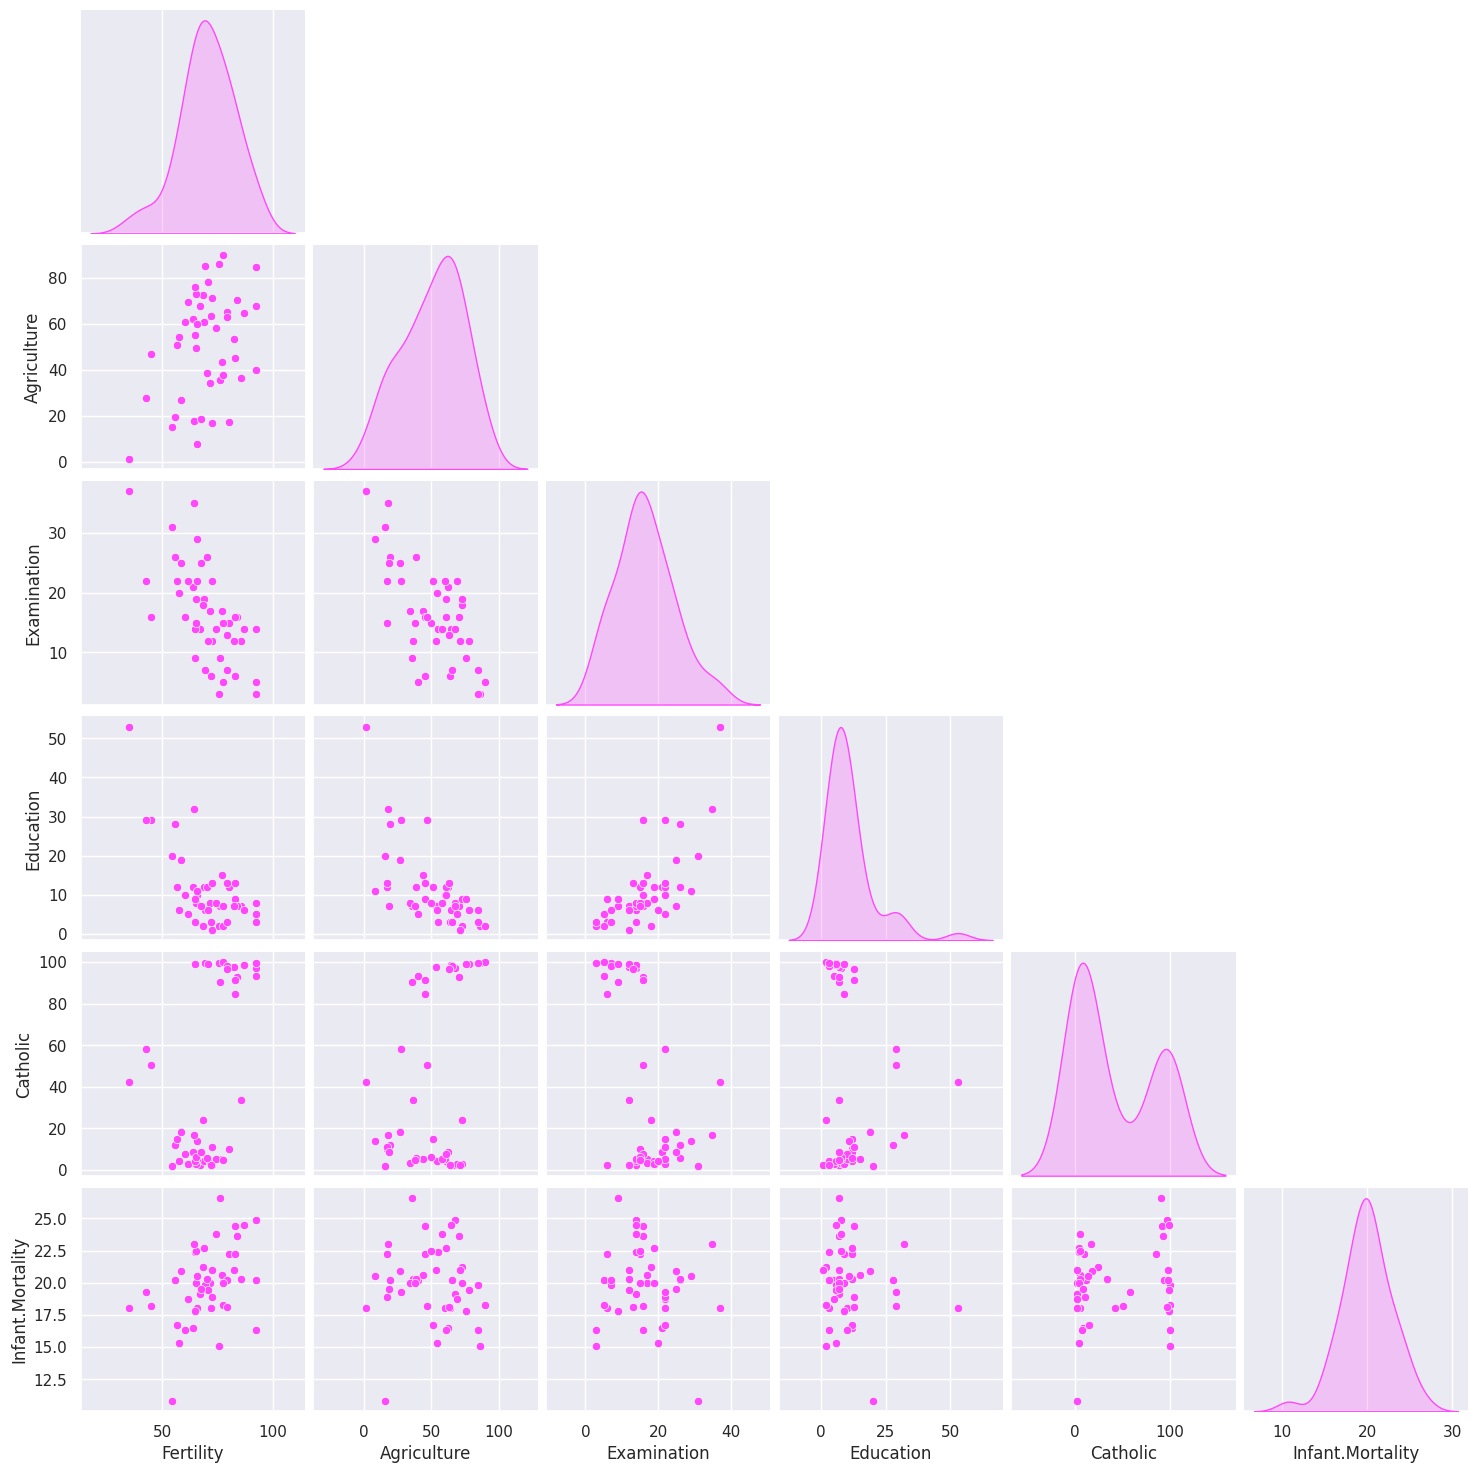

In [179]:
sns.pairplot(data=dataset_with_dummies,
             diag_kind="kde", corner=True,
                plot_kws={'color':
                        '#ff48fd'},
                diag_kws={'color':
                         '#ff48fd'}
             );

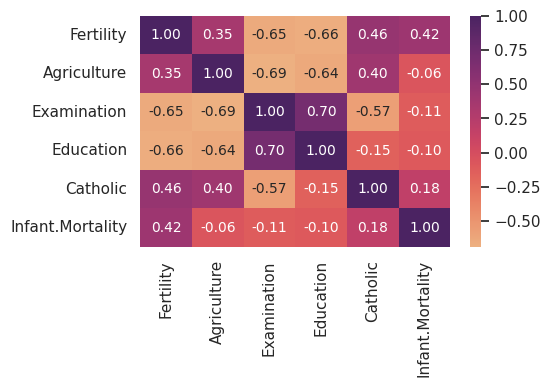

In [180]:
correlacion_profit = dataset_with_dummies.corr()

plt.figure(figsize=(5, 3))
sns.heatmap(correlacion_profit, annot=True, cmap='flare', annot_kws={"size": 10},
    fmt=".2f", cbar=True)
plt.show()

In [181]:
X = df.drop(columns='Examination')
y = df["Examination"]

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=42
                                                    )

# Datos de train y de test
print("Dimensión de X_train:",X_train.shape)
print("Valores de y_train:",y_train.size)
print("Dimensión de X_test:",X_test.shape)
print("Valores de y_test:",len(y_test))

Dimensión de X_train: (32, 6)
Valores de y_train: 32
Dimensión de X_test: (15, 6)
Valores de y_test: 15


In [183]:
# 1. Escalar los atributos usando `StandardScaler`
from sklearn.preprocessing import StandardScaler

r_d_spend = X_train[["Education"]]

sc_r_d_spend = StandardScaler()
r_d_spend_scaled = sc_r_d_spend.fit_transform(r_d_spend)

print(f"La media del escalador es {np.round(sc_r_d_spend.mean_[0], 2)}")
print(f"El desvío estándar del escalador es "
    f"{np.round(np.sqrt(sc_r_d_spend.var_[0]), 2)}")


La media del escalador es 12.56
El desvío estándar del escalador es 10.91


In [184]:
r_d_spend = pd.concat([r_d_spend.reset_index(drop=True),
    pd.DataFrame({"scaled": r_d_spend_scaled.squeeze()})], axis=1)
r_d_spend.head(10)

,Education,scaled
0,12,-0.051565
1,28,1.415177
2,53,3.706960
3,2,-0.968279
4,13,0.040106
5,8,-0.418251
6,8,-0.418251
7,2,-0.968279
8,29,1.506848
9,12,-0.051565


In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definimos qué columnas son categóricas y cuáles numéricas
categorical_columns = ['Location']
numerical_columns = ['Fertility', 'Agriculture', 'Education', 'Catholic', 'Infant.Mortality']

# Creamos el preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        # Codificamos las categorías
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns),
        # Escalamos las variables numéricas
        ('num', StandardScaler(), numerical_columns)
    ]
)

# Creamos el pipeline con preprocesamiento y modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())  # Aplicamos la regresión lineal
])

In [186]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Location']),
                                                 ('num', StandardScaler(),
                                                  ['Fertility', 'Agriculture',
                                                   'Education', 'Catholic',
                                                   'Infant.Mortality'])])),
                ('regressor', LinearRegression())])

In [187]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Location']),
                                                 ('num', StandardScaler(),
                                                  ['Fertility', 'Agriculture',
                                                   'Education', 'Catholic',
                                                   'Infant.Mortality'])])),
                ('regressor', LinearRegression())])

In [188]:
print(f"El valor de la intersección de la recta es "
    f"{np.round(pipeline.named_steps['regressor'].intercept_, 2)}")
print(f"Los valores de los coeficientes de la recta son "
    f" {np.round(pipeline.named_steps['regressor'].coef_, 2)}")

El valor de la intersección de la recta es 17.03
Los valores de los coeficientes de la recta son  [-2.3   4.83 -3.4   4.01 -5.77 -5.17  3.79 -0.95 -3.59  4.36 -2.46 -1.29
  5.66 -1.83  0.22  1.68 -2.62  5.56  2.09  1.75  0.01 -7.96 -0.81  3.67
  0.96 -0.41  0.76 -4.    2.29  5.71 -3.91  0.46  0.16  5.47 -4.62 -0.16]


In [189]:
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['cat__Location_Avenches', 'cat__Location_Boudry',
       'cat__Location_Conthey', 'cat__Location_Cossonay',
       'cat__Location_Courtelary', 'cat__Location_Delemont',
       'cat__Location_Echallens', 'cat__Location_Entremont',
       'cat__Location_Franches-Mnt', 'cat__Location_Glane',
       'cat__Location_Grandson', 'cat__Location_Herens',
       'cat__Location_La Vallee', 'cat__Location_Lausanne',
       'cat__Location_Monthey', 'cat__Location_Morges',
       'cat__Location_Moudon', 'cat__Location_Neuchatel',
       'cat__Location_Nyone', 'cat__Location_Orbe',
       'cat__Location_Porrentruy', 'cat__Location_Rive Droite',
       'cat__Location_Rive Gauche', 'cat__Location_Sarine',
       'cat__Location_Sion', 'cat__Location_St Maurice',
       'cat__Location_V. De Geneve', 'cat__Location_Val de Ruz',
       'cat__Location_Vevey', 'cat__Location_Veveyse',
       'cat__Location_Yverdon', 'num__Fertility', 'num__Agriculture',
       'num__Education', 'num__Catholic', 'num__I

In [190]:
print(f"El coeficiente de determinación (R^2) es {pipeline.score(X_train, y_train)}") # Q tan bien aprendi[o el modelo

El coeficiente de determinación (R^2) es 1.0


In [191]:
y_model = pipeline.predict(X_train)
num_attributes = len(pipeline.named_steps['preprocessor'].get_feature_names_out())

std_dev_model = np.sqrt((
    np.sum((y_train - y_model)**2))/(y_train.size - num_attributes - 1))
print(f"Desvío estándar del modelo {round(std_dev_model, 3)}")

Desvío estándar del modelo nan


/tmp/ipykernel_682/2661637145.py:4: RuntimeWarning: invalid value encountered in sqrt
  std_dev_model = np.sqrt((


In [192]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)



In [193]:
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [194]:
# 4. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.

In [195]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("R-cuadrado en test:", round(r2, 3))
print("Error absoluto medio:", round(mae, 3))
print("Error cuadrático medio:", round(mse, 3))
print("Raíz de error cuadrático medio:", round(rmse, 3))
print(f"Error absoluto porcentual medio: {mape*100:.2f}%")

R-cuadrado en test: 0.203
Error absoluto medio: 5.121
Error cuadrático medio: 33.421
Raíz de error cuadrático medio: 5.781
Error absoluto porcentual medio: 47.51%


In [196]:
mean_profit = np.mean(y_train)

y_pred_baseline = np.full_like(y_test, mean_profit)

In [197]:
r2_baseline = r2_score(y_test, y_pred_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("R-cuadrado en test:", round(r2_baseline, 3))
print("Error absoluto medio:", round(mae_baseline, 3)) # Si estás prediciendo salarios y el MAE da 500, significa que, en promedio, tus predicciones fallan por $500 de diferencia con respecto al valor real
print("Error cuadrático medio:", round(mse_baseline, 3)) # Al elevar al cuadrado, castiga severamente los errores grandes. Si el modelo se equivoca por 2, el castigo es 4; si se equivoca por 10, el castigo es 100. Es excelente para los matemáticos durante el entrenamiento, pero difícil de interpretar a simple vista porque las unidades quedan al cuadrado (ej: "dólares al cuadrado").
print("Raiz de error cuadrático medio:", round(rmse_baseline, 3)) # Resuelve el problema del MSE devolviendo el error a la unidad de medida original. Al igual que el MAE, te dice cuánto se equivoca el modelo en promedio, pero el RMSE siempre será más alto si tu modelo cometió un par de errores extremadamente graves (falsas alarmas muy grandes).
print(f"Error absoluto porcentual medio: {mape_baseline*100:.2f}%") # Si da 5.21%, significa que, en promedio, tus predicciones tienen un margen de error del 5.21% con respecto al valor real. Es sumamente útil porque no depende de la escala de tus datos.

R-cuadrado en test: -0.072
Error absoluto medio: 5.333
Error cuadrático medio: 44.933
Raiz de error cuadrático medio: 6.703
Error absoluto porcentual medio: 65.24%


In [198]:
'''
import joblib

with open('reg_completo_50_startup.pkl', 'wb') as archivo:
    joblib.dump(pipeline, archivo)
    '''

"\nimport joblib\n\nwith open('reg_completo_50_startup.pkl', 'wb') as archivo:\n    joblib.dump(pipeline, archivo)\n    "

## Modelo con regularización

Para mejorar nuestro modelo, vamos a explorar técnicas de regresión lineal con regularización, que nos permiten controlar el sobreajuste y seleccionar variables relevantes automáticamente.

Existen dos variantes muy populares:

- Una penaliza la suma de los cuadrados de los coeficientes (regularización L2).
- La otra penaliza la suma del valor absoluto de los coeficientes (regularización L1).

Ambas ayudan a mejorar la generalización, pero una de ellas además puede eliminar variables (coeficientes exactamente cero), lo que ayuda a identificar qué atributos son realmente importantes.

Tu tarea:

1. Elegí correctamente cuál de los dos métodos de regularización usar para este problema.
    - Pista: Queremos que el modelo sea capaz de hacer una selección automática de variables, dejando fuera aquellas que no aportan.
2. Implementá un pipeline que incluya escalado y el modelo elegido.
3. Buscá automáticamente el mejor valor del hiperparámetro de regularización (alpha) usando validación cruzada usando 3-folds.
4. Entrená el modelo con los datos de entrenamiento y obtené las predicciones para el set de testeo.
5. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.
6. Imprimí los coeficientes resultantes e identificá qué variables fueron eliminadas (coeficiente = 0).

In [199]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set()
from sklearn.linear_model import LassoCV, RidgeCV

Paremos un momento para entender qué hacen LassoCV y RidgeCV antes de continuar con la resolución:

> Tanto `LassoCV` como `RidgeCV` son implementaciones de regresión lineal con regularización que incluyen la búsqueda automática del mejor hiperparámetro alpha mediante validación cruzada.
>
> Ambos métodos prueban distintos valores de alpha y eligen el que minimiza el error del modelo, facilitando el proceso de ajuste sin necesidad de una búsqueda manual.
>
> Internamente, utilizan la métrica del error cuadrático medio (MSE) para evaluar el rendimiento del modelo en cada fold de la validación cruzada.
>
> Por ejemplo, si llamás a RidgeCV(alphas=alphas, cv=5), se hará una validación cruzada de 5 folds utilizando los valores de alpha que vos le pases, y se seleccionará el que obtenga el menor MSE promedio.
>
> Una vez elegido el mejor alpha, el modelo final se entrena con todos los datos de entrenamiento usando ese valor.

¡Listo! Con todo lo que vimos hasta ahora, ya estás en condiciones de resolver esta parte y completar los 6 puntos propuestos

In [200]:
alphas = np.logspace(-4, 1, 500)




In [201]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Examination')
y = df["Examination"]

# Usamos random_state=42 para asegurar que el split del dataset sea consistente con el
# notebook anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_columns = ['Location']
numerical_columns = ['Fertility', 'Agriculture', 'Education', 'Catholic', 'Infant.Mortality']

# Creamos el preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

In [203]:
X_train_processed = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())

X_train_processed.head()


ValueError: Shape of passed values is (32, 1), indices imply (32, 36)

In [ ]:
from sklearn.linear_model import Lasso, Ridge


In [ ]:
from sklearn.linear_model import LinearRegression

coeffs_lasso = np.zeros([5000, 5])
coeffs_ridge = np.zeros([5000, 5])

alpha_array_plot = np.arange(0, 10000, 2)

# Calculamos los coeficientes para diferentes valores de lambda
for index, alpha in enumerate(alpha_array_plot):

    # Creamos los modelos
    lasso_model = Lasso(alpha=alpha)
    ridge_model = Ridge(alpha=alpha)

    # Si alpha es cero, significa que es una regresión lineal
    if index == 0:
        lasso_model = LinearRegression()
        ridge_model = LinearRegression()

    # Los entrenamos
    lasso_model.fit(X_train_processed, y_train)
    ridge_model.fit(X_train_processed, y_train)

    # Guardamos los coeficientes de las regresiones
    coeffs_lasso[index, :] = lasso_model.coef_.copy()
    coeffs_ridge[index, :] = ridge_model.coef_.copy()

In [ ]:
num_lines = coeffs_lasso.shape[1]
colormap = ["#00FFFF", "#FF00FF", "#FF1493", "#00BFFF", "#FF6347"]

f, ax = plt.subplots(1, 2, figsize=(9, 3.5))

for i in range(num_lines):
    ax[0].plot(alpha_array_plot, coeffs_lasso[:, i], color=colormap[i])
    ax[1].plot(alpha_array_plot, coeffs_ridge[:, i],
        label=X_train_processed.columns[i], color=colormap[i])

ax[1].legend()
ax[0].set_xlim([-100, 8000])
ax[1].set_xlim([-100, 4000])

ax[0].set_ylabel("Coeficientes")
ax[0].set_xlabel("alpha")
ax[1].set_xlabel("alpha")

ax[0].set_title("Lasso (L1)")
ax[1].set_title("Ridge (L2)")

plt.tight_layout()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

alpha_array = np.arange(0, 1000, 0.25)

# Validación cruzada de 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Donde vamos a almacenar los errores
cv_ridge_errors = []
cv_lasso_errors = []

# Búsqueda del mejor alpha usando un loop
for alpha in alpha_array:
    fold_ridge_errors = []
    fold_lasso_errors = []

    # Realizar la validación cruzada
    for train_idx, val_idx in kf.split(X_train_processed):
        X_train_fold, X_val_fold = X_train_processed.iloc[train_idx, :], \
            X_train_processed.iloc[val_idx, :]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Crear y entrenar el modelo de Ridge
        ridge = Ridge(alpha=alpha)
        lasso = Lasso(alpha=alpha)
        if alpha == 0:
            ridge = LinearRegression()
            lasso = LinearRegression()

        ridge.fit(X_train_fold, y_train_fold)
        lasso.fit(X_train_fold, y_train_fold)

        # Hacer las predicciones sobre el fold de validación
        y_pred_ridge = ridge.predict(X_val_fold)
        y_pred_lasso = lasso.predict(X_val_fold)

        # Calcular el error cuadrático medio para el fold
        mse_ridge = mean_absolute_error(y_val_fold, y_pred_ridge)
        mse_lasso = mean_absolute_error(y_val_fold, y_pred_lasso)
        fold_ridge_errors.append(mse_ridge)
        fold_lasso_errors.append(mse_lasso)

    # Calcular el error medio para este alpha
    cv_ridge_errors.append(np.mean(fold_ridge_errors))
    cv_lasso_errors.append(np.mean(fold_lasso_errors))

# Mostramos cual es el mejor valor de alpha para cada caso
best_alpha_ridge = alpha_array[np.argmin(cv_ridge_errors)]
best_alpha_lasso = alpha_array[np.argmin(cv_lasso_errors)]
print(f"El mejor valor de alpha para Ridge es: {best_alpha_ridge}")
print(f"El mejor valor de alpha para Lasso es: {best_alpha_lasso}")

In [ ]:
from sklearn.pipeline import Pipeline

categorical_columns = ['State']
numerical_columns = ['R&D Spend', 'Administration', 'Marketing Spend']

# Creamos el preprocesamiento para las columnas de ambos modelos
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ]
)
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ]
)

# Creamos los pipelines
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('regressor', Ridge(alpha=best_alpha_ridge))  # Aplicamos la regresión lineal
])
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('regressor', Lasso(alpha=best_alpha_lasso))  # Aplicamos la regresión lineal
])

pipeline_ridge.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)

# Evaluamos el modelo de Ridge
y_pred = pipeline_ridge.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Regresión de Ridge")
print("------------------")
print("R-cuadrado en test:", round(r2, 3))
print("Error absoluto medio:", round(mae, 3))
print("Error cuadrático medio:", round(mse, 3))
print("Raíz de error cuadrático medio:", round(rmse, 3))
print(f"Error absoluto porcentual medio: {mape*100:.2f}%")

In [ ]:
# Evaluamos el modelo de Lasso
y_pred = pipeline_lasso.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Regresión de Lasso")
print("------------------")
print("R-cuadrado en test:", round(r2, 3))
print("Error absoluto medio:", round(mae, 3))
print("Error cuadrático medio:", round(mse, 3))
print("Raíz de error cuadrático medio:", round(rmse, 3))
print(f"Error absoluto porcentual medio: {mape*100:.2f}%")

In [ ]:
print("Los valores de los coeficientes de Lasso son "
    f"{np.round(pipeline_lasso.named_steps['regressor'].coef_, 2)}")

In [ ]:
plt.figure(figsize=(5, 3))

num_lines = coeffs_lasso.shape[1]
colors = ["#00FFFF", "#FF00FF", "#FF1493", "#00BFFF", "#FF6347"]

for i in range(coeffs_lasso.shape[1]):
    plt.plot(alpha_array_plot, coeffs_lasso[:, i],
        label=X_train_processed.columns[i], color=colors[i])

plt.plot([best_alpha_lasso, best_alpha_lasso], [-5000, 100_000], 'k--')

plt.text(best_alpha_lasso + 100, 30_000, f'Mejor alpha = {best_alpha_lasso:.2f}',
    color='black', verticalalignment='bottom', horizontalalignment='left', fontsize=10)


plt.ylim([-4000, 40_000])
plt.xlim([-100, 8000])
plt.xlabel("alpha")
plt.title("Lasso (L1)")

plt.tight_layout();

In [ ]:
'''
import joblib

with open('lasso_50_startup.pkl', 'wb') as archivo:
    joblib.dump(pipeline_lasso, archivo)
    '''

## Comparación de modelos y conclusiones

Completá la siguiente tabla con las métricas obtenidas para cada uno de los modelos que entrenaste:

| Modelo                        | MAE | MSE | $R^2$ |
| ----------------------------- | --- | --- | ----- |
| Regresión Lineal              |     |     |       |
| Modelo Regularizado (L1 o L2) |     |     |       |


> ⚠️ Asegurate de cambiar el nombre del modelo `Modelo Regularizado (L1 o L2)` según el modelo que usaste (Lasso o Ridge).

### Justificación

**¿Cuál de los modelos te parece que tuvo un mejor desempeño general?**

Tené en cuenta las tres métricas al responder, y también pensá en la complejidad del modelo (por ejemplo, si eliminó variables innecesarias).

Escribí tu respuesta a continuación:

ESCRIBA AQUI SU RESPUESTA